<a href="https://colab.research.google.com/github/Mvdu12/brain_tumor_detection/blob/main/brain_tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection from MRI Scans
## Deep Learning Comparative Study — Custom CNN · VGG16 · ResNet50

| Item | Detail |
|---|---|
| **Task 1** | Binary classification — Tumor (`yes`) vs No Tumor (`no`) |
| **Task 2** | Multi-class — Healthy · Glioma · Meningioma · Pituitary |
| **Framework** | TensorFlow / Keras |
| **Pre-trained weights** | ImageNet (VGG16, ResNet50) |
| **Dataset structure** | `brain_tumor_dataset/yes/` and `brain_tumor_dataset/no/` |


In [22]:
# =============================================================================
# CELL 1 — Libraries & Reusable Helper Functions
# =============================================================================
# Standard libraries
import os
import random

# Numerical & image processing
import numpy as np
import cv2                        # OpenCV — image reading and contour detection
import imutils                    # Convenience wrappers around OpenCV

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Scikit-learn — splitting and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow / Keras — models, layers, training utilities
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16    import VGG16
from tensorflow.keras.applications.vgg16    import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# -----------------------------------------------------------------------------
# HELPER: crop_brain_roi
# Removes the black padding around an MRI scan and returns only the brain region.
# How it works:
#   1. Convert to grayscale and blur to reduce noise.
#   2. Binary-threshold to separate brain (white) from background (black).
#   3. Erode then dilate to clean up small artefacts.
#   4. Find the largest external contour (= the brain).
#   5. Crop tightly to its extreme left/right/top/bottom points.
# If no contour is found (rare edge-case), the original image is returned unchanged.
# -----------------------------------------------------------------------------
def crop_brain_roi(mri_image):
    gray_image   = cv2.cvtColor(mri_image, cv2.COLOR_BGR2GRAY)
    blurred_gray = cv2.GaussianBlur(gray_image, (5, 5), 0)

    # Threshold: pixels > 45 become white (brain), rest black (background)
    binary_mask = cv2.threshold(blurred_gray, 45, 255, cv2.THRESH_BINARY)[1]
    binary_mask = cv2.erode(binary_mask,  None, iterations=2)
    binary_mask = cv2.dilate(binary_mask, None, iterations=2)

    all_contours = cv2.findContours(binary_mask.copy(),
                                    cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    all_contours = imutils.grab_contours(all_contours)

    if len(all_contours) == 0:
        return mri_image                        # Nothing to crop — return as-is

    largest_contour = max(all_contours, key=cv2.contourArea)

    # Find the four extreme points of the brain contour
    leftmost_point  = tuple(largest_contour[largest_contour[:, :, 0].argmin()][0])
    rightmost_point = tuple(largest_contour[largest_contour[:, :, 0].argmax()][0])
    topmost_point   = tuple(largest_contour[largest_contour[:, :, 1].argmin()][0])
    bottommost_point= tuple(largest_contour[largest_contour[:, :, 1].argmax()][0])

    # Slice the image to keep only the bounding box of the brain
    cropped_brain = mri_image[
        topmost_point[1]  : bottommost_point[1],
        leftmost_point[0] : rightmost_point[0]
    ]
    return cropped_brain


# -----------------------------------------------------------------------------
# HELPER: plot_accuracy_and_loss
# Draws two side-by-side line charts from a Keras History object:
#   Left  → Training vs Validation Accuracy over epochs
#   Right → Training vs Validation Loss over epochs
# -----------------------------------------------------------------------------
def plot_accuracy_and_loss(training_history, model_name="Model"):
    train_acc   = training_history.history['accuracy']
    val_acc     = training_history.history['val_accuracy']
    train_loss  = training_history.history['loss']
    val_loss    = training_history.history['val_loss']
    epoch_range = range(len(train_acc))

    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {model_name}', fontsize=14, fontweight='bold')

    ax_acc.plot(epoch_range, train_acc, label='Train',      linewidth=2)
    ax_acc.plot(epoch_range, val_acc,   label='Validation', linewidth=2, linestyle='--')
    ax_acc.set_title('Accuracy over Epochs')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

    ax_loss.plot(epoch_range, train_loss, label='Train',      linewidth=2)
    ax_loss.plot(epoch_range, val_loss,   label='Validation', linewidth=2, linestyle='--')
    ax_loss.set_title('Loss over Epochs')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss Value')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# HELPER: plot_confusion_matrix
# Renders a colour-coded confusion matrix heatmap using seaborn.
# Parameters:
#   true_labels  — ground-truth integer labels
#   pred_labels  — predicted integer labels
#   class_names  — human-readable label list, e.g. ['no', 'yes']
#   chart_title  — string shown as the chart title
#   color_map    — matplotlib colormap name (default 'Blues')
# -----------------------------------------------------------------------------
def plot_confusion_matrix(true_labels, pred_labels, class_names, chart_title, color_map='Blues'):
    confusion_mat = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap=color_map,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(chart_title, fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


print("✅ All libraries imported and helper functions defined.")


✅ All libraries imported and helper functions defined.


In [23]:
# List the contents of the .rar file to understand its internal structure
!unrar l /content/brain_tumor_dataset.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal

Archive: /content/brain_tumor_dataset.rar
Details: RAR 5

 Attributes      Size     Date    Time   Name
----------- ---------  ---------- -----  ----
    ..A....     54521  2019-10-21 18:48  brain_tumor_dataset/no/1 no.jpeg
    ..A....      3848  2019-10-21 18:48  brain_tumor_dataset/no/10 no.jpg
    ..A....      3475  2019-10-21 18:48  brain_tumor_dataset/no/11 no.jpg
    ..A....      4142  2019-10-21 18:48  brain_tumor_dataset/no/12 no.jpg
    ..A....      4570  2019-10-21 18:48  brain_tumor_dataset/no/13 no.jpg
    ..A....      6039  2019-10-21 18:48  brain_tumor_dataset/no/14 no.jpg
    ..A....      6924  2019-10-21 18:48  brain_tumor_dataset/no/15 no.jpg
    ..A....      5400  2019-10-21 18:48  brain_tumor_dataset/no/17 no.jpg
    ..A....      5868  2019-10-21 18:48  brain_tumor_dataset/no/18 no.jpg
    ..A....      5843  2019-10-21 18:48  brain_tumor_dataset/no/19 no.jpg
    ..A....     79678  2019-10-21 1

In [29]:
print('Extracting brain_tumor_dataset.rar...')
!unrar x /content/brain_tumor_dataset.rar
print('Extraction complete. Please re-run cell TjaTpARK74nd to load the dataset.')

Extracting brain_tumor_dataset.rar...

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/brain_tumor_dataset.rar

Creating    brain_tumor_dataset                                       OK
Creating    brain_tumor_dataset/no                                    OK
Extracting  brain_tumor_dataset/no/1 no.jpeg                               0%  OK 
Extracting  brain_tumor_dataset/no/10 no.jpg                               0%  OK 
Extracting  brain_tumor_dataset/no/11 no.jpg                               0%  OK 
Extracting  brain_tumor_dataset/no/12 no.jpg                               0%  OK 
Extracting  brain_tumor_dataset/no/13 no.jpg                               0%  OK 
Extracting  brain_tumor_dataset/no/14 no.jpg                               0%  OK 
Extracting  brain_tumor_dataset/no/15 no.jpg                               1%  OK 
Extracting  brain_tumor_dataset/no/17 no.jpg  

In [30]:
 # =============================================================================
# CELL 2 — Load Binary Dataset (Tumor / No Tumor)
# =============================================================================
# Expected folder structure on your machine:
#
#   brain_tumor_dataset/
#   ├── no/     ← MRI scans WITHOUT a tumour
#   └── yes/    ← MRI scans WITH a tumour
#
# The loader will:
#   1. Walk the /kaggle/input tree looking for any folder that contains
#      both a "yes" and a "no" sub-folder.
#   2. Read every .jpg/.jpeg/.png image inside those sub-folders.
#   3. Apply crop_brain_roi() to remove black padding.
#   4. Resize to BINARY_IMG_SIZE and normalise pixel values to [0, 1].
#   5. Return numpy arrays X (images) and y (labels: 0=no, 1=yes).
# =============================================================================

BINARY_IMG_SIZE = (224, 224)    # Input size expected by VGG16 and ResNet50

# Integer ↔ string mappings used throughout the binary section
BINARY_INT_TO_LABEL = {0: 'no', 1: 'yes'}
BINARY_LABEL_TO_INT = {'no': 0, 'yes': 1}


def locate_binary_dataset():
    """
    Searches for the binary dataset in common locations (Colab, Kaggle).
    Returns the path string on success, or None if not found.
    """
    # Common Colab data upload location (checking for nested folder from .rar extraction)
    colab_path_nested = '/content/brain_tumor_dataset/brain_tumor_dataset'
    print(f"DEBUG: Checking nested path: {colab_path_nested}")
    if os.path.exists(colab_path_nested):
        print(f"DEBUG: {colab_path_nested} exists.")
        dir_contents = os.listdir(colab_path_nested)
        print(f"DEBUG: Contents of {colab_path_nested}: {dir_contents}")
        if 'yes' in dir_contents and 'no' in dir_contents:
            print(f"✅ Binary dataset found at: {colab_path_nested}")
            return colab_path_nested
        else:
            print(f"DEBUG: 'yes' or 'no' not found in {colab_path_nested}")
    else:
        print(f"DEBUG: {colab_path_nested} does NOT exist.")

    # Original Colab path (in case it's not nested for some reason)
    colab_path = '/content/brain_tumor_dataset'
    print(f"DEBUG: Checking original Colab path: {colab_path}")
    if os.path.exists(colab_path):
        print(f"DEBUG: {colab_path} exists.")
        dir_contents = os.listdir(colab_path)
        print(f"DEBUG: Contents of {colab_path}: {dir_contents}")
        if 'yes' in dir_contents and 'no' in dir_contents:
            print(f"✅ Binary dataset found at: {colab_path}")
            return colab_path
        else:
            print(f"DEBUG: 'yes' or 'no' not found in {colab_path}")
    else:
        print(f"DEBUG: {colab_path} does NOT exist.")

    # Kaggle input dataset location (assuming common Kaggle path)
    kaggle_specific_path = '/kaggle/input/brain-tumor-dataset'
    print(f"DEBUG: Checking Kaggle specific path: {kaggle_specific_path}")
    if os.path.exists(kaggle_specific_path):
        print(f"DEBUG: {kaggle_specific_path} exists.")
        dir_contents = os.listdir(kaggle_specific_path)
        print(f"DEBUG: Contents of {kaggle_specific_path}: {dir_contents}")
        if 'yes' in dir_contents and 'no' in dir_contents:
            print(f"✅ Binary dataset found at: {kaggle_specific_path}")
            return kaggle_specific_path
        else:
            print(f"DEBUG: 'yes' or 'no' not found in {kaggle_specific_path}")
    else:
        print(f"DEBUG: {kaggle_specific_path} does NOT exist.")


    # Generic recursive search in /kaggle/input
    print("DEBUG: Starting recursive search in /kaggle/input...")
    for folder_root, sub_dirs, _ in os.walk('/kaggle/input'):
        print(f"DEBUG: Checking folder_root: {folder_root}, sub_dirs: {sub_dirs}")
        if 'yes' in sub_dirs and 'no' in sub_dirs:
            print(f"✅ Binary dataset found at: {folder_root}")
            return folder_root

    print("❌ Could not find the binary dataset.")
    print("   Please upload the 'brain_tumor_dataset' folder (containing 'yes/' and 'no/' subfolders) to /content/")
    print("   or ensure it's mounted correctly from Kaggle if using Kaggle datasets.")
    return None


def load_binary_mri_images(dataset_folder, target_size=BINARY_IMG_SIZE):
    """
    Loads all MRI images from dataset_folder/yes/ and dataset_folder/no/,
    applies brain-ROI cropping, resizes, and normalises them.

    Returns:
        image_array  — float32 numpy array of shape (N, H, W, 3)
        label_array  — int numpy array of shape (N,), values 0 or 1
        label_lookup — dict mapping int → class name string
    """
    if dataset_folder is None:
        return None, None, None

    image_list = []
    label_list = []

    for class_name, integer_label in BINARY_LABEL_TO_INT.items():
        class_folder = os.path.join(dataset_folder, class_name)

        for filename in os.listdir(class_folder):
            # Skip any non-image files that may be in the folder
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            raw_image = cv2.imread(os.path.join(class_folder, filename))
            if raw_image is None:
                continue                            # Skip unreadable files

            cropped_image  = crop_brain_roi(raw_image)
            resized_image  = cv2.resize(cropped_image, target_size,
                                        interpolation=cv2.INTER_CUBIC)
            normalised_img = resized_image / 255.0  # Scale from [0,255] → [0,1]

            image_list.append(normalised_img)
            label_list.append(integer_label)

    image_array = np.array(image_list)
    label_array = np.array(label_list)

    tumor_count    = int(label_array.sum())
    no_tumor_count = int((label_array == 0).sum())
    print(f"✅ Loaded {len(image_array)} images")
    print(f"   Tumor (yes): {tumor_count}  |  No Tumor (no): {no_tumor_count}")

    return image_array, label_array, BINARY_INT_TO_LABEL


# Run the loader
binary_dataset_root    = locate_binary_dataset()
all_images, all_labels, label_lookup = load_binary_mri_images(binary_dataset_root)

DEBUG: Checking nested path: /content/brain_tumor_dataset/brain_tumor_dataset
DEBUG: /content/brain_tumor_dataset/brain_tumor_dataset does NOT exist.
DEBUG: Checking original Colab path: /content/brain_tumor_dataset
DEBUG: /content/brain_tumor_dataset exists.
DEBUG: Contents of /content/brain_tumor_dataset: ['no', 'yes']
✅ Binary dataset found at: /content/brain_tumor_dataset
✅ Loaded 253 images
   Tumor (yes): 155  |  No Tumor (no): 98


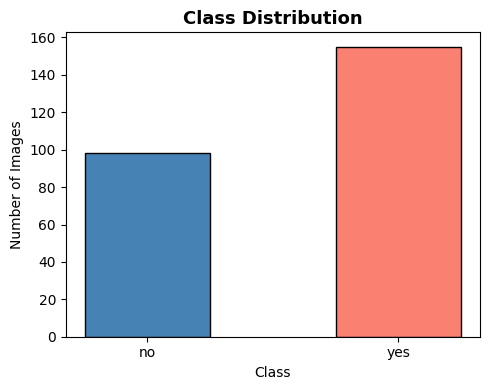

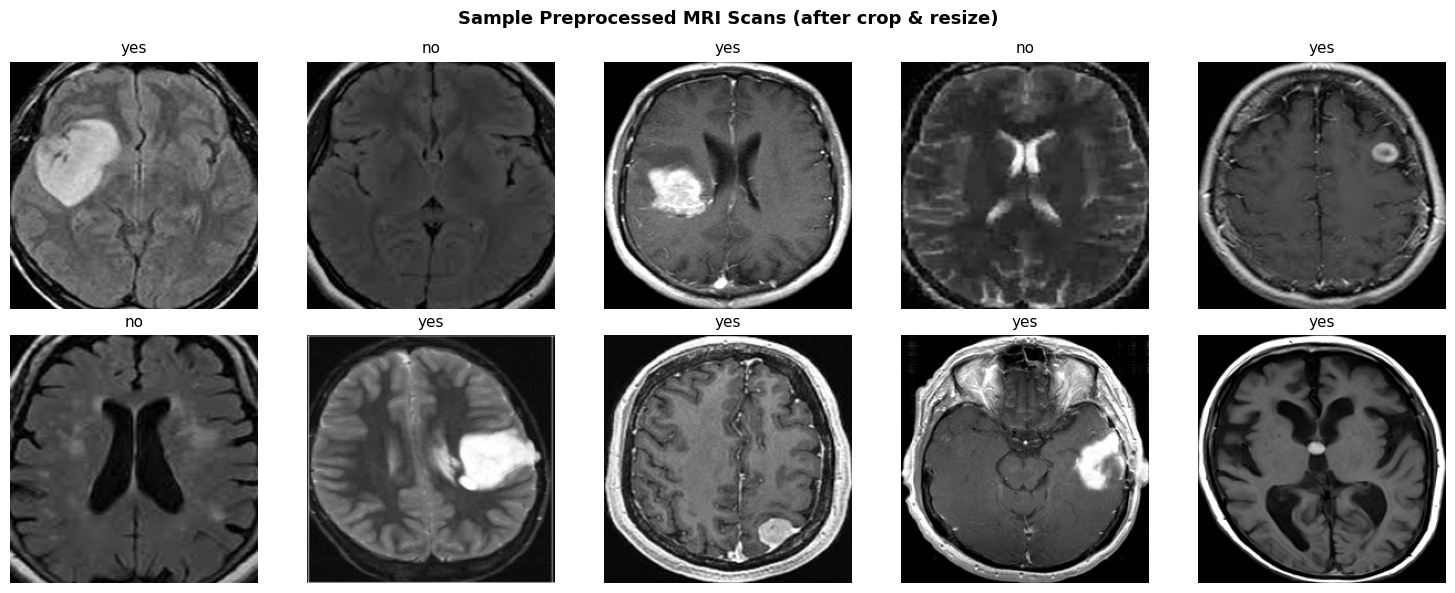

In [31]:
# =============================================================================
# CELL 3 — Exploratory Data Analysis (EDA)
# =============================================================================
# Before training we visualise:
#   (a) Class distribution — check for class imbalance.
#   (b) A random grid of 10 preprocessed scans — sanity-check the loader.
# =============================================================================

if all_images is not None:

    # ── (a) Class distribution bar chart ─────────────────────────────────────
    unique_classes, class_counts = np.unique(all_labels, return_counts=True)
    bar_colors = ['steelblue', 'salmon']

    plt.figure(figsize=(5, 4))
    plt.bar([label_lookup[cls] for cls in unique_classes],
            class_counts,
            color=bar_colors,
            edgecolor='black',
            width=0.5)
    plt.title('Class Distribution', fontsize=13, fontweight='bold')
    plt.ylabel('Number of Images')
    plt.xlabel('Class')
    plt.tight_layout()
    plt.show()

    # ── (b) Random sample grid ────────────────────────────────────────────────
    # Pick 10 random indices so the grid shows variety rather than the first images
    random_sample_indices = random.sample(range(len(all_images)), 10)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Sample Preprocessed MRI Scans (after crop & resize)',
                 fontsize=13, fontweight='bold')

    for axis, sample_idx in zip(axes.flat, random_sample_indices):
        axis.imshow(all_images[sample_idx])
        axis.set_title(label_lookup[all_labels[sample_idx]], fontsize=11)
        axis.axis('off')

    plt.tight_layout()
    plt.show()


In [32]:
# =============================================================================
# CELL 4 — Train / Validation Split & Data Augmentation Setup
# =============================================================================
# We split 80 % for training and 20 % for validation.
# stratify=y keeps the class ratio identical in both splits.
#
# Data augmentation (applied only to training images during .flow()):
#   - rotation_range=10 : rotate ±10 degrees — MRI scans can be slightly tilted
#   - horizontal_flip   : mirror left↔right — the brain is roughly symmetric
#   - fill_mode='nearest': fill any empty pixels from rotation with the
#                          nearest real pixel value
# NOTE: augmentation does NOT change the stored arrays — it generates new
#       variations on-the-fly inside the training loop.
# =============================================================================

# Before splitting, ensure that all_images and all_labels are not None.
# If they are None, it means the dataset loading in the previous cell failed.
if all_images is None or all_labels is None:
    print("❌ Dataset not loaded. Please ensure cell TjaTpARK74nd ran successfully and loaded data.")
else:
    # Split into training and validation sets
    train_images, val_images, train_labels, val_labels = train_test_split(
        all_images, all_labels,
        test_size=0.20,
        random_state=42,      # Fixed seed for reproducibility
        stratify=all_labels   # Maintain class ratio in both splits
    )

    print(f"Training samples  : {len(train_images)}")
    print(f"Validation samples: {len(val_images)}")

    # Augmentation generator — applies random transforms each epoch
    binary_augmentor = ImageDataGenerator(
        rotation_range=10,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Callbacks shared by all three binary models:
    #   EarlyStopping    → stop training when val_loss stops improving for 10 epochs
    #                      and restore the best weights seen during training
    #   ReduceLROnPlateau→ cut the learning rate by ×0.1 if val_loss plateaus for 4 epochs
    binary_training_callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.1,
            patience=4,
            min_lr=1e-7,
            verbose=1
        )
    ]

    print("\n✅ Data split and augmentation ready.")



Training samples  : 202
Validation samples: 51

✅ Data split and augmentation ready.


In [33]:
# =============================================================================
# CELL 5 — Model A: VGG16 Transfer Learning
# =============================================================================
# Architecture:
#   VGG16 (frozen ImageNet weights)
#     └─ GlobalAveragePooling2D   — reduce spatial dimensions to a 512-d vector
#     └─ Dense(256, relu)         — learn task-specific features
#     └─ BatchNormalization       — stabilise and speed up training
#     └─ Dropout(0.5)             — randomly zero 50 % of units to prevent overfitting
#     └─ Dense(1, sigmoid)        — output probability of "tumor present"
#
# Why freeze VGG16?
#   ImageNet features (edges, textures, shapes) transfer well to medical images.
#   Freezing them lets us train only the small head, which is faster and avoids
#   destroying the pre-trained representations with a large gradient.
# =============================================================================

vgg16_base_model = VGG16(
    weights='imagenet',
    include_top=False,              # Drop the original 1000-class classifier
    input_shape=(224, 224, 3)
)
vgg16_base_model.trainable = False  # Lock all VGG16 weights

vgg16_classifier = models.Sequential([
    vgg16_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')   # 1 output → binary cross-entropy
], name='VGG16_BrainTumor')

vgg16_classifier.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),  # Low LR — fine-tuning a big base
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg16_classifier.summary()


Model: "VGG16_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 132,097 (516.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

🚀 Training VGG16 (Transfer Learning) …
Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5693 - loss: 0.8028 - val_accuracy: 0.3529 - val_loss: 0.7162 - learning_rate: 1.0000e-04
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 420ms/step - accuracy: 0.5446 - loss: 0.7873 - val_accuracy: 0.4314 - val_loss: 0.6994 - learning_rate: 1.0000e-04
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 591ms/step - accuracy: 0.5792 - loss: 0.7100 - val_accuracy: 0.5686 - val_loss: 0.6865 - learning_rate: 1.0000e-04
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 474ms/step - accuracy: 0.6188 - loss: 0.7275 - val_accuracy: 0.6275 - val_loss: 0.6747 - learning_rate: 1.0000e-04
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.6634 - loss: 0.6376 - val_accuracy: 0.6275 - val_loss: 0.6657 - learning_rate: 1.0000e-04
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 409ms/step - accuracy: 0.6238 - loss: 0.6994 - val_accuracy: 0.6078 - val_loss: 0.6579 - learning_rate: 1.0000e-04
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 

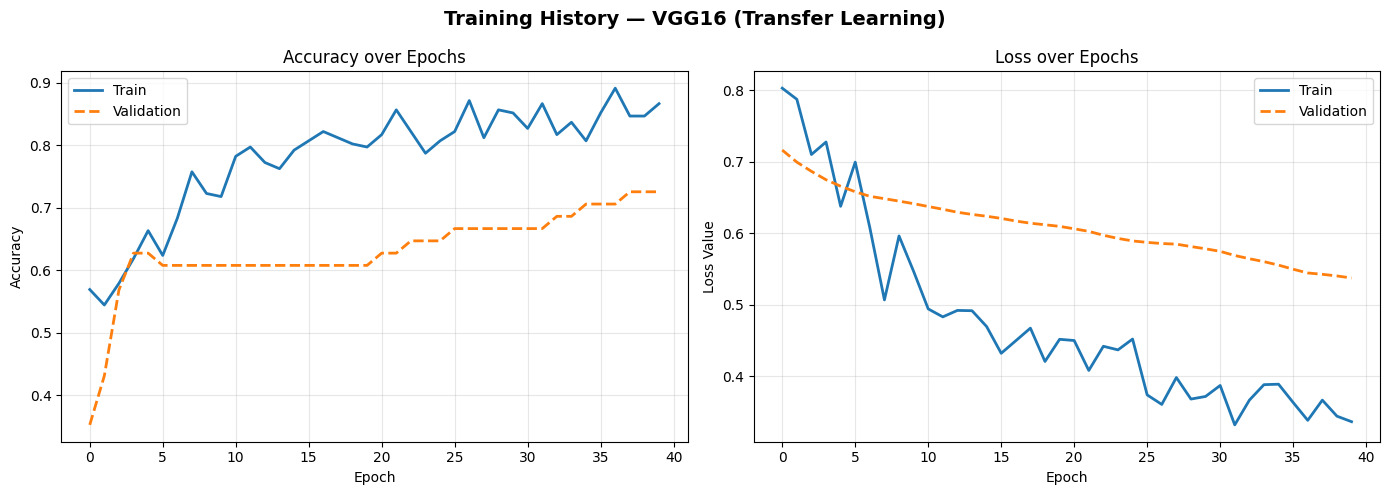

In [34]:
# =============================================================================
# CELL 6 — Train VGG16
# =============================================================================
# batch_size=32  : standard choice — balances memory and gradient stability
# epochs=40      : EarlyStopping will halt before this if val_loss stops falling
# =============================================================================

print("🚀 Training VGG16 (Transfer Learning) …")
vgg16_train_history = vgg16_classifier.fit(
    binary_augmentor.flow(train_images, train_labels, batch_size=32),
    validation_data=(val_images, val_labels),
    epochs=40,
    callbacks=binary_training_callbacks,
    verbose=1
)

plot_accuracy_and_loss(vgg16_train_history, model_name='VGG16 (Transfer Learning)')


In [35]:
# =============================================================================
# CELL 7 — Model B: Custom CNN (trained from scratch)
# =============================================================================
# Architecture — three convolutional blocks followed by a classifier head:
#
#   Block 1: Conv2D(32)  → BatchNorm → MaxPool(2×2)
#   Block 2: Conv2D(64)  → BatchNorm → MaxPool(2×2)
#   Block 3: Conv2D(128) → BatchNorm → MaxPool(2×2)
#   Head:    GlobalAveragePooling → Dense(256) → Dropout(0.5) → Dense(1, sigmoid)
#
# Each block doubles the number of filters (32→64→128) so the network learns
# progressively more complex features at smaller spatial resolutions.
# BatchNormalization after each conv layer normalises activations which speeds
# up convergence and acts as a mild regulariser.
# =============================================================================

def build_custom_binary_cnn(input_shape=(224, 224, 3)):
    """
    Constructs a 3-block convolutional neural network for binary MRI classification.
    Args:
        input_shape: (height, width, channels) — default matches VGG16/ResNet50 input.
    Returns:
        Compiled Keras Sequential model.
    """
    cnn_model = models.Sequential([
        # ── Convolutional Block 1: detect low-level features (edges, corners) ──
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Convolutional Block 2: detect mid-level features (textures) ────────
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Convolutional Block 3: detect high-level features (shapes, anatomy) ─
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ── Classifier Head ────────────────────────────────────────────────────
        layers.GlobalAveragePooling2D(),    # Collapse spatial dims → 1-D feature vector
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),               # Drop 50 % of units to prevent overfitting
        layers.Dense(1, activation='sigmoid')
    ], name='CustomCNN_BrainTumor')

    cnn_model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return cnn_model


custom_binary_cnn = build_custom_binary_cnn()
custom_binary_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CustomCNN_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,425 (497.75 KB)

 Trainable params: 126,977 (496.00 KB)

 Non-trainable params: 448 (1.75 KB)

🚀 Training Custom CNN (from scratch) …
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4208 - loss: 0.7748 - val_accuracy: 0.6078 - val_loss: 0.6911 - learning_rate: 1.0000e-04
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 487ms/step - accuracy: 0.6089 - loss: 0.6701 - val_accuracy: 0.4706 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step - accuracy: 0.6386 - loss: 0.6676 - val_accuracy: 0.5490 - val_loss: 0.6941 - learning_rate: 1.0000e-04
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.7134 - loss: 0.6279
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 0.6584 - loss: 0.6322 - val_accuracy: 0.3922 - val_loss: 0.6953 - learning_rate: 1.0000e-04
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 0.6188 - loss: 0.6623 - val_accuracy: 0.3922 - val_loss: 0.6974 - learning_rate: 1.0000e-05
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms

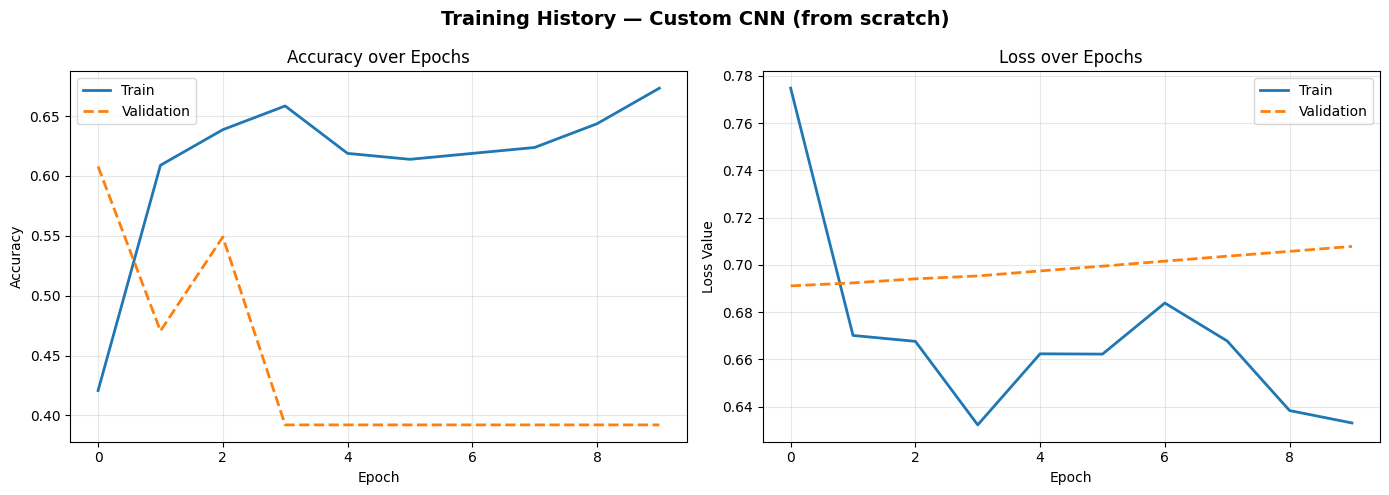

In [36]:
# =============================================================================
# CELL 8 — Train Custom CNN
# =============================================================================

print("🚀 Training Custom CNN (from scratch) …")
custom_cnn_train_history = custom_binary_cnn.fit(
    binary_augmentor.flow(train_images, train_labels, batch_size=32),
    validation_data=(val_images, val_labels),
    epochs=30,
    callbacks=binary_training_callbacks,
    verbose=1
)

plot_accuracy_and_loss(custom_cnn_train_history, model_name='Custom CNN (from scratch)')


In [37]:
# =============================================================================
# CELL 9 — Model C: ResNet50 Fine-tuning
# =============================================================================
# Strategy — partial fine-tuning:
#   • All ResNet50 layers EXCEPT the last 10 are frozen.
#   • The last 10 layers (deepest residual blocks) are unfrozen so they can
#     adapt their high-level features to MRI scans specifically.
#   • A very low learning rate (1e-5) prevents destructive updates to the
#     already well-trained lower layers.
#
# The Lambda preprocessing layer reverses our [0,1] normalisation back to
# [0,255] and then applies ResNet50's expected mean-subtraction so the
# pre-trained statistics are still valid.
# =============================================================================

resnet50_base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze the model first, then re-freeze everything except the last 10 layers
resnet50_base_model.trainable = True
for individual_layer in resnet50_base_model.layers[:-10]:
    individual_layer.trainable = False

resnet50_classifier = models.Sequential([
    # Undo [0,1] normalisation → apply ResNet50's expected preprocessing
    layers.Lambda(
        lambda pixel_values: resnet50_preprocess(pixel_values * 255.0),
        input_shape=(224, 224, 3)
    ),
    resnet50_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
], name='ResNet50_BrainTumor')

resnet50_classifier.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # Very low LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet50_classifier.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ResNet50_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 4,990,465 (19.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

🚀 Training ResNet50 (Fine-tuned) …
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6040 - loss: 0.7769 - val_accuracy: 0.5882 - val_loss: 0.8443 - learning_rate: 1.0000e-05
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.6386 - loss: 0.6664 - val_accuracy: 0.5686 - val_loss: 0.6986 - learning_rate: 1.0000e-05
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.6881 - loss: 0.6025 - val_accuracy: 0.6078 - val_loss: 0.6220 - learning_rate: 1.0000e-05
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7468 - loss: 0.5413
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.7525 - loss: 0.5448 - val_accuracy: 0.6863 - val_loss: 0.5796 - learning_rate: 1.0000e-05
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy: 0.8366 - loss: 0.4274 - val_accuracy: 0.6863 - val_loss: 0.5638 - learning_rate: 1.0000e-06
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━

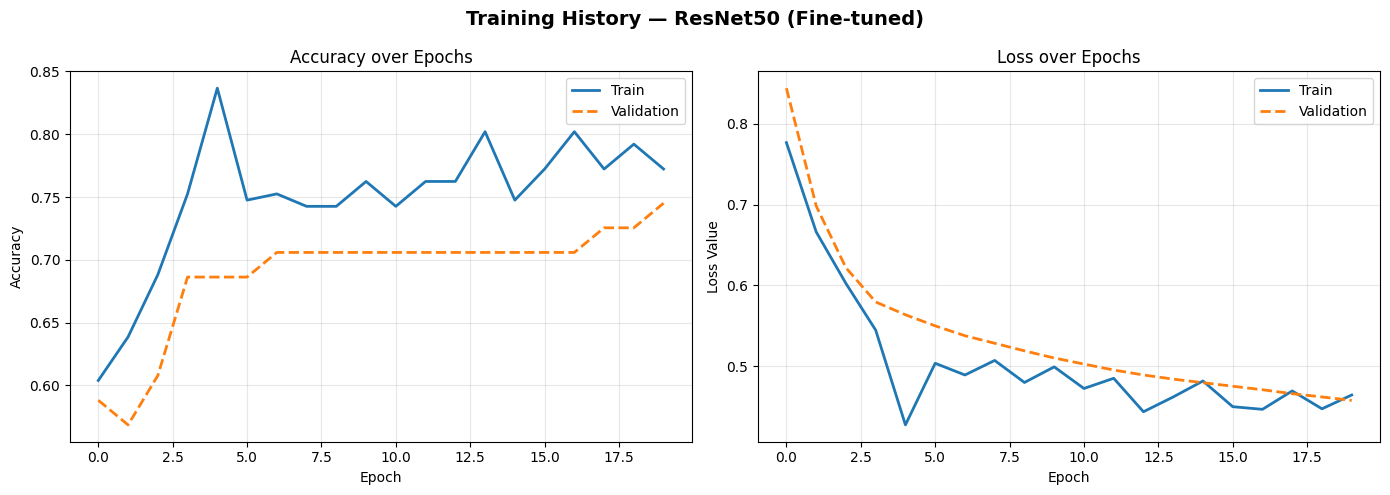

In [38]:
# =============================================================================
# CELL 10 — Train ResNet50
# =============================================================================
# Smaller batch_size=16 used here because ResNet50 has more parameters and
# consumes more GPU memory per image than VGG16 or the custom CNN.
# =============================================================================

print("🚀 Training ResNet50 (Fine-tuned) …")
resnet50_train_history = resnet50_classifier.fit(
    binary_augmentor.flow(train_images, train_labels, batch_size=16),
    validation_data=(val_images, val_labels),
    epochs=20,
    callbacks=binary_training_callbacks,
    verbose=1
)

plot_accuracy_and_loss(resnet50_train_history, model_name='ResNet50 (Fine-tuned)')



───────────────────────────────────────────────────────
  VGG16 (Transfer Learning)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

          no       0.88      0.35      0.50        20
         yes       0.70      0.97      0.81        31

    accuracy                           0.73        51
   macro avg       0.79      0.66      0.66        51
weighted avg       0.77      0.73      0.69        51



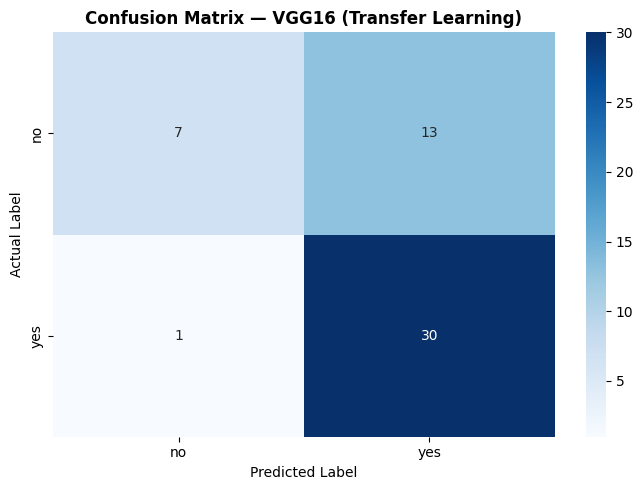


───────────────────────────────────────────────────────
  Custom CNN (from scratch)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

          no       0.00      0.00      0.00        20
         yes       0.61      1.00      0.76        31

    accuracy                           0.61        51
   macro avg       0.30      0.50      0.38        51
weighted avg       0.37      0.61      0.46        51



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


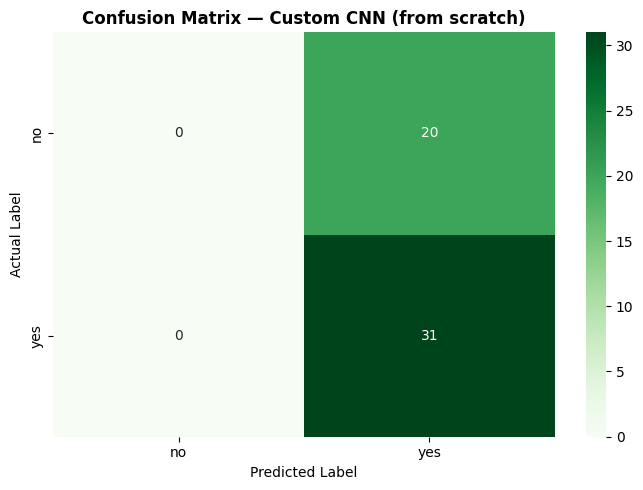


───────────────────────────────────────────────────────
  ResNet50 (Fine-tuned)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

          no       0.89      0.40      0.55        20
         yes       0.71      0.97      0.82        31

    accuracy                           0.75        51
   macro avg       0.80      0.68      0.69        51
weighted avg       0.78      0.75      0.72        51



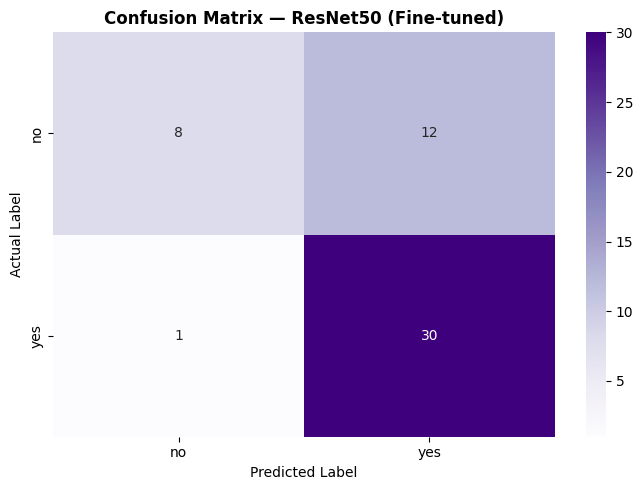

In [39]:
# =============================================================================
# CELL 11 — Binary Classification: Evaluation of All Three Models
# =============================================================================
# For each model we:
#   1. Run predictions on the held-out validation set.
#   2. Convert raw sigmoid probabilities to class labels (threshold = 0.5).
#   3. Print a full classification report (precision, recall, F1, support).
#   4. Display a confusion matrix heatmap.
# =============================================================================

binary_class_names = list(label_lookup.values())   # ['no', 'yes']

# (model_name, trained_model, confusion_matrix_colormap)
binary_model_registry = [
    ('VGG16 (Transfer Learning)', vgg16_classifier,   'Blues'),
    ('Custom CNN (from scratch)', custom_binary_cnn,  'Greens'),
    ('ResNet50 (Fine-tuned)',      resnet50_classifier,'Purples'),
]

for model_display_name, trained_model, heatmap_color in binary_model_registry:
    # Predict: output is a probability in [0,1]; threshold at 0.5
    raw_probabilities   = trained_model.predict(val_images, verbose=0)
    predicted_int_labels = (raw_probabilities > 0.5).astype('int32').flatten()

    print(f"\n{'─'*55}")
    print(f"  {model_display_name}")
    print(f"{'─'*55}")
    print(classification_report(val_labels, predicted_int_labels,
                                target_names=binary_class_names))

    plot_confusion_matrix(
        true_labels=val_labels,
        pred_labels=predicted_int_labels,
        class_names=binary_class_names,
        chart_title=f'Confusion Matrix — {model_display_name}',
        color_map=heatmap_color
    )


In [40]:
# =============================================================================
# CELL 12 — Binary Results Summary Table
# =============================================================================
# Aggregates the peak validation accuracy and lowest validation loss for each
# model into a single pandas DataFrame sorted best → worst.
# =============================================================================

binary_results_dict = {
    'Model': [
        'VGG16 (Transfer Learning)',
        'Custom CNN (from scratch)',
        'ResNet50 (Fine-tuned)'
    ],
    'Best Validation Accuracy (%)': [
        round(max(vgg16_train_history.history['val_accuracy'])     * 100, 2),
        round(max(custom_cnn_train_history.history['val_accuracy'])* 100, 2),
        round(max(resnet50_train_history.history['val_accuracy'])  * 100, 2),
    ],
    'Best Validation Loss': [
        round(min(vgg16_train_history.history['val_loss']),     4),
        round(min(custom_cnn_train_history.history['val_loss']),4),
        round(min(resnet50_train_history.history['val_loss']),  4),
    ]
}

binary_results_df = pd.DataFrame(binary_results_dict)
binary_results_df = binary_results_df.sort_values('Best Validation Accuracy (%)',
                                                   ascending=False)

print("🏆 Binary Classification — Final Comparison")
display(binary_results_df.reset_index(drop=True))


🏆 Binary Classification — Final Comparison


,Model,Best Validation Accuracy (%),Best Validation Loss
0,ResNet50 (Fine-tuned),74.51,0.4577
1,VGG16 (Transfer Learning),72.55,0.5373
2,Custom CNN (from scratch),60.78,0.6911


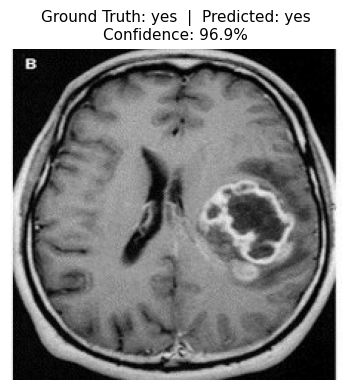

In [41]:
# =============================================================================
# CELL 13 — Single-Image Prediction Demo (Binary — ResNet50)
# =============================================================================
# Picks one random image from the validation set, runs it through ResNet50,
# and displays the result alongside the ground-truth label.
# =============================================================================

demo_sample_index = random.randint(0, len(val_images) - 1)
demo_image        = val_images[demo_sample_index]
ground_truth      = label_lookup[val_labels[demo_sample_index]]

# expand_dims adds the batch dimension: (224,224,3) → (1,224,224,3)
tumor_probability = resnet50_classifier.predict(
    np.expand_dims(demo_image, axis=0), verbose=0
)[0][0]

predicted_class   = 'yes' if tumor_probability > 0.5 else 'no'
# Confidence = probability of the predicted class (not always tumor probability)
prediction_confidence = tumor_probability * 100 if predicted_class == 'yes'                         else (1 - tumor_probability) * 100

plt.figure(figsize=(4, 4))
plt.imshow(demo_image)
plt.title(
    f"Ground Truth: {ground_truth}  |  Predicted: {predicted_class}\n"
    f"Confidence: {prediction_confidence:.1f}%",
    fontsize=11
)
plt.axis('off')
plt.tight_layout()
plt.show()


---
## Part 2 — Multi-Class Classification
### 4 Classes: Healthy · Glioma · Meningioma · Pituitary

**Dataset structure expected:**
```
brain-tumor-mri-dataset/
├── Training/
│   ├── notumor/
│   ├── glioma/
│   ├── meningioma/
│   └── pituitary/
└── Testing/
    ├── notumor/
    ├── glioma/
    ├── meningioma/
    └── pituitary/
```


In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [46]:
# =============================================================================
# CELL 14 — Load Multi-Class Dataset (4 tumour types)
# =============================================================================
# The multi-class dataset uses a different folder structure: it has separate
# Training/ and Testing/ directories, each containing 4 class sub-folders.
# We merge both splits into a single pool and re-split with stratification.
#
# max_images_per_class=600 keeps memory manageable and the class distribution
# balanced when the raw class sizes are unequal.
# =============================================================================

MULTICLASS_DATASET_PATH = '/kaggle/input/brain-tumor-mri-dataset'
MULTICLASS_IMG_SIZE     = (128, 128)   # Smaller than 224 — reduces memory for 4-class task

# Integer labels for the four classes
MULTICLASS_LABEL_MAP  = {'notumor': 0, 'glioma': 1, 'meningioma': 2, 'pituitary': 3}
MULTICLASS_CLASS_NAMES = ['Healthy', 'Glioma', 'Meningioma', 'Pituitary']


def load_multiclass_mri_images(dataset_root, target_size=MULTICLASS_IMG_SIZE,
                                max_images_per_class=600):
    """
    Loads MRI images for 4-class brain tumour classification.

    Scans both Training/ and Testing/ sub-directories.
    Caps each class at max_images_per_class to maintain balance.

    Returns:
        image_array — float32 numpy array (N, H, W, 3), pixel values in [0,1]
        label_array — int numpy array (N,), values 0–3
    """
    image_list = []
    label_list = []

    for dataset_split in ['Training', 'Testing']:
        split_folder = os.path.join(dataset_root, dataset_split)

        if not os.path.exists(split_folder):
            print(f"⚠️  Folder not found: {split_folder} — skipping.")
            continue

        for class_folder_name, integer_label in MULTICLASS_LABEL_MAP.items():
            class_folder_path = os.path.join(split_folder, class_folder_name)

            if not os.path.exists(class_folder_path):
                continue

            # Collect valid image filenames (up to the per-class cap)
            valid_files = [
                f for f in os.listdir(class_folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ][:max_images_per_class]

            for image_filename in valid_files:
                raw_img = cv2.imread(os.path.join(class_folder_path, image_filename))
                if raw_img is None:
                    continue

                resized_img     = cv2.resize(raw_img, target_size)
                normalised_img  = (resized_img / 255.0).astype(np.float32)

                image_list.append(normalised_img)
                label_list.append(integer_label)

    multiclass_images = np.array(image_list)
    multiclass_labels = np.array(label_list)

    # Print per-class counts so we can verify balance
    unique_cls, cls_counts = np.unique(multiclass_labels, return_counts=True)
    for cls_idx, count in zip(unique_cls, cls_counts):
        print(f"  {MULTICLASS_CLASS_NAMES[cls_idx]:12s}: {count} images")
    print(f"  Total: {len(multiclass_images)}")

    return multiclass_images, multiclass_labels


print("⏳ Loading multi-class MRI dataset …")
multiclass_images, multiclass_labels = load_multiclass_mri_images(MULTICLASS_DATASET_PATH)

# Stratified split so each class is proportionally represented in both sets
mc_train_images, mc_val_images, mc_train_labels, mc_val_labels = train_test_split(
    multiclass_images, multiclass_labels,
    test_size=0.20,
    random_state=42,
    stratify=multiclass_labels
)

print(f"\n✅ Multi-class split — Train: {len(mc_train_images)}  |  Validation: {len(mc_val_images)}")


⏳ Loading multi-class MRI dataset …
  Healthy     : 1000 images
  Glioma      : 1000 images
  Meningioma  : 1000 images
  Pituitary   : 1000 images
  Total: 4000

✅ Multi-class split — Train: 3200  |  Validation: 800


In [47]:
# =============================================================================
# CELL 15 — Build & Train All Three Multi-Class Models
# =============================================================================
# All models output a 4-neuron softmax layer and use
# sparse_categorical_crossentropy loss (labels are plain integers, not one-hot).
# =============================================================================

multiclass_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                     patience=3, min_lr=1e-7, verbose=1)
]

# ──────────────────────────────────────────────────────────────────────────────
# A. Custom CNN — trained from scratch on 128×128 images
# ──────────────────────────────────────────────────────────────────────────────
mc_custom_cnn = models.Sequential([
    # Block 1 — low-level feature detection
    layers.Conv2D(32,  (3,3), activation='relu', padding='same',
                  input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 2 — mid-level feature detection
    layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 3 — high-level feature detection
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 classes
], name='MC_CustomCNN')

mc_custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Training Multi-class Custom CNN …")
mc_custom_cnn_history = mc_custom_cnn.fit(
    mc_train_images, mc_train_labels,
    validation_data=(mc_val_images, mc_val_labels),
    epochs=20, callbacks=multiclass_callbacks, verbose=1
)

# ──────────────────────────────────────────────────────────────────────────────
# B. ResNet50 — frozen base (feature extractor only)
# ──────────────────────────────────────────────────────────────────────────────
resnet50_mc_base = ResNet50(weights='imagenet', include_top=False,
                             input_shape=(128, 128, 3))
resnet50_mc_base.trainable = False   # Use ResNet purely as a fixed feature extractor

mc_resnet50 = models.Sequential([
    resnet50_mc_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
], name='MC_ResNet50')

mc_resnet50.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Training Multi-class ResNet50 …")
mc_resnet50_history = mc_resnet50.fit(
    mc_train_images, mc_train_labels,
    validation_data=(mc_val_images, mc_val_labels),
    epochs=20, callbacks=multiclass_callbacks, verbose=1
)

# ──────────────────────────────────────────────────────────────────────────────
# C. VGG16 — frozen base (feature extractor only)
# ──────────────────────────────────────────────────────────────────────────────
vgg16_mc_base = VGG16(weights='imagenet', include_top=False,
                       input_shape=(128, 128, 3))
vgg16_mc_base.trainable = False

mc_vgg16 = models.Sequential([
    vgg16_mc_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
], name='MC_VGG16')

mc_vgg16.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Training Multi-class VGG16 …")
mc_vgg16_history = mc_vgg16.fit(
    mc_train_images, mc_train_labels,
    validation_data=(mc_val_images, mc_val_labels),
    epochs=20, callbacks=multiclass_callbacks, verbose=1
)

print("\n✅ All multi-class models finished training.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🚀 Training Multi-class Custom CNN …
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.5597 - loss: 1.0526 - val_accuracy: 0.2412 - val_loss: 1.4077 - learning_rate: 1.0000e-04
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6531 - loss: 0.8693 - val_accuracy: 0.2500 - val_loss: 1.6181 - learning_rate: 1.0000e-04
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6900 - loss: 0.8042 - val_accuracy: 0.2500 - val_loss: 1.6897 - learning_rate: 1.0000e-04
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7088 - loss: 0.7394
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7103 - loss: 0.7289 - val_accuracy: 0.3088 - val_loss: 1.7007 - learning_rate: 1.0000e-04
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7425 - loss: 0.6753 - val_accuracy: 0.4863 - val_loss: 1.1614 - learning_rate: 2.0000e-05
Epoch 6/20
100/100 ━━━━━━

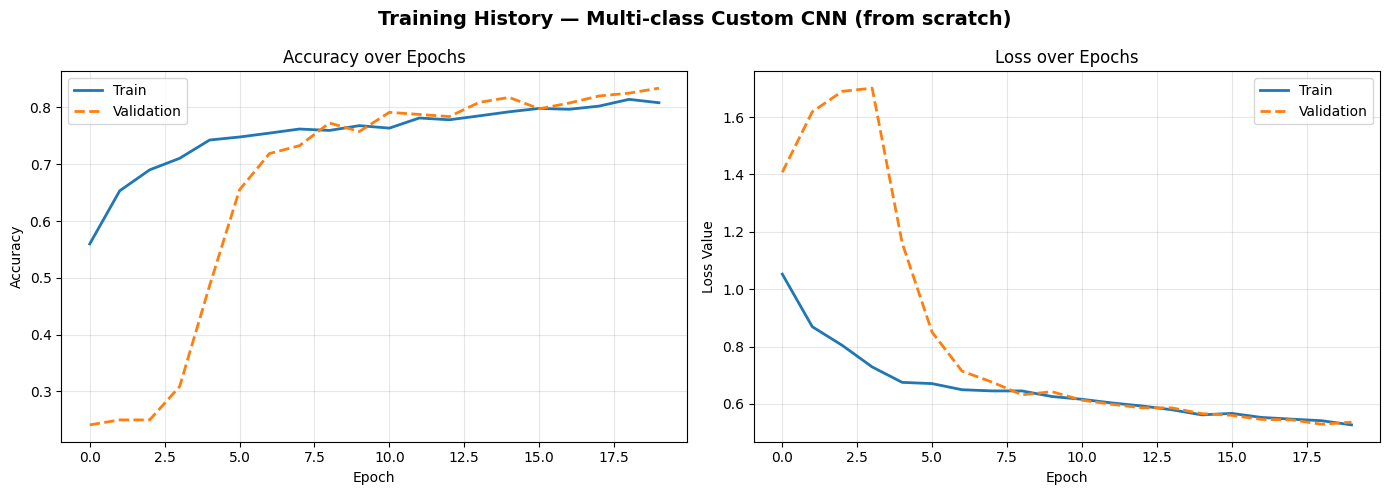


────────────────────────────────────────────────────────────
  Custom CNN (from scratch)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Healthy       0.87      0.91      0.89       200
      Glioma       0.89      0.73      0.80       200
  Meningioma       0.72      0.71      0.71       200
   Pituitary       0.84      0.94      0.89       200

    accuracy                           0.82       800
   macro avg       0.83      0.82      0.82       800
weighted avg       0.83      0.82      0.82       800



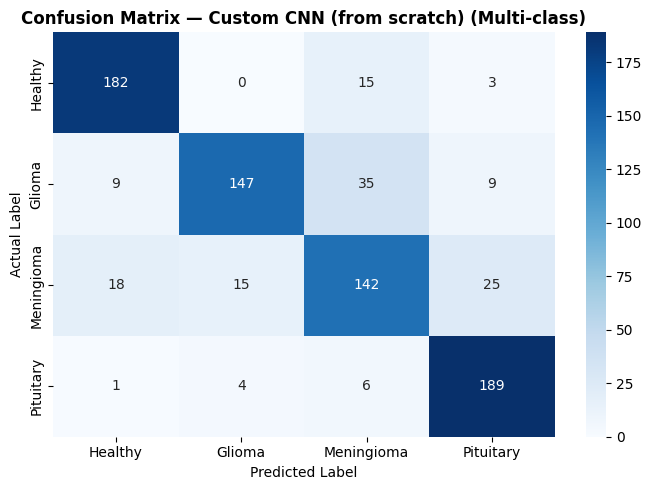

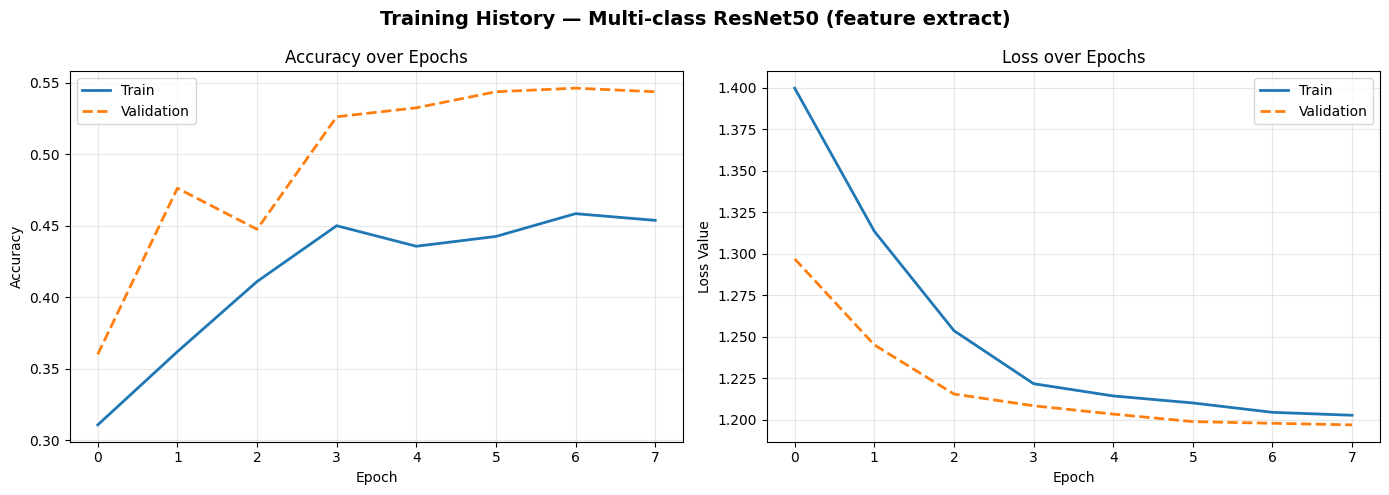


────────────────────────────────────────────────────────────
  ResNet50 (feature extract)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Healthy       0.79      0.51      0.62       200
      Glioma       0.00      0.00      0.00       200
  Meningioma       0.28      0.93      0.43       200
   Pituitary       0.67      0.01      0.02       200

    accuracy                           0.36       800
   macro avg       0.43      0.36      0.27       800
weighted avg       0.43      0.36      0.27       800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


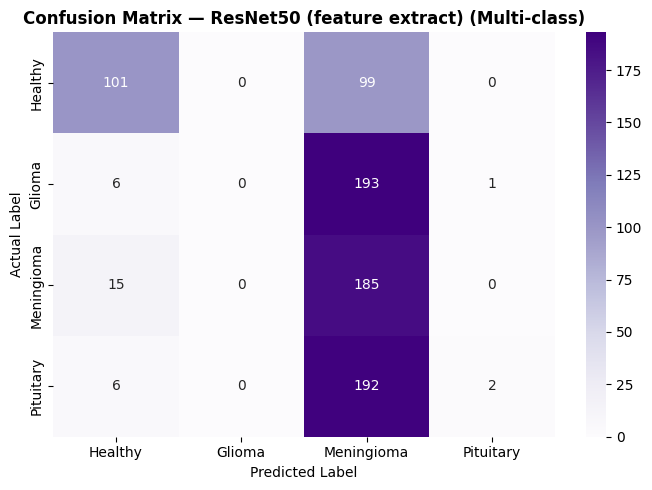

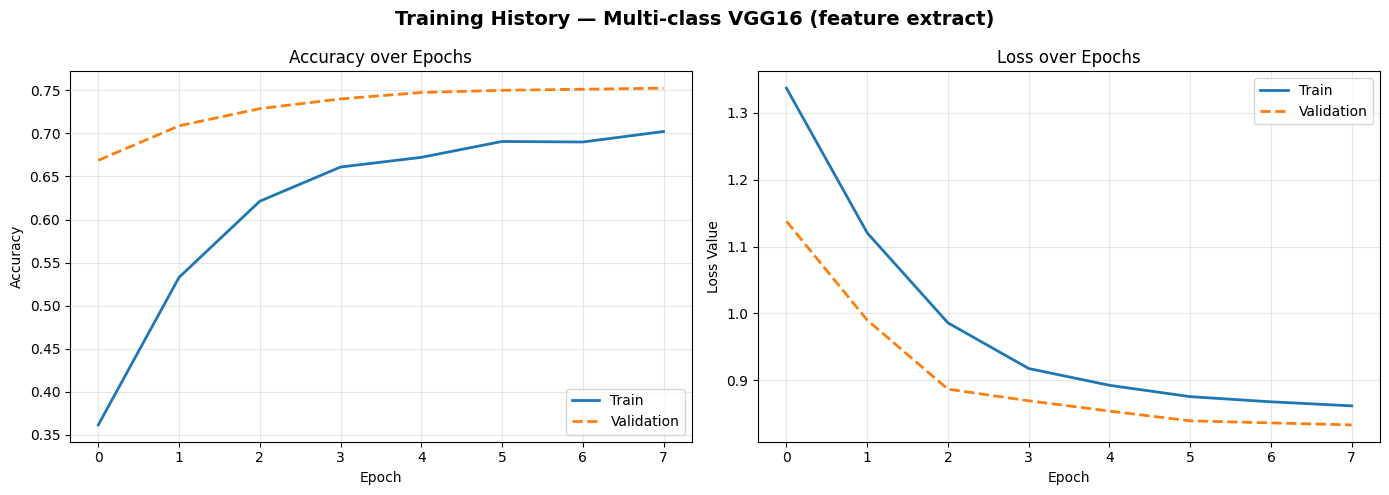


────────────────────────────────────────────────────────────
  VGG16 (feature extract)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Healthy       0.69      0.93      0.79       200
      Glioma       0.70      0.60      0.65       200
  Meningioma       0.57      0.46      0.51       200
   Pituitary       0.70      0.69      0.69       200

    accuracy                           0.67       800
   macro avg       0.66      0.67      0.66       800
weighted avg       0.66      0.67      0.66       800



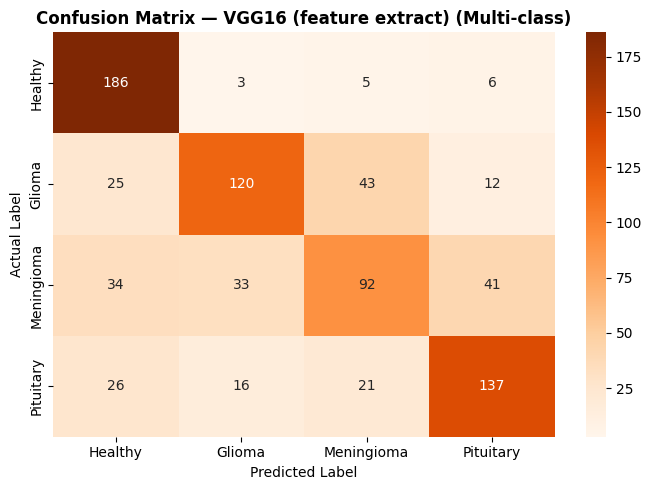

In [48]:
# =============================================================================
# CELL 16 — Multi-Class Evaluation: Reports & Confusion Matrices
# =============================================================================
# For multi-class outputs we use np.argmax to convert the 4-probability softmax
# vector to a single predicted class integer (0–3).
# =============================================================================

multiclass_model_registry = [
    ('Custom CNN (from scratch)', mc_custom_cnn,  mc_custom_cnn_history,  'Blues'),
    ('ResNet50 (feature extract)', mc_resnet50,   mc_resnet50_history,    'Purples'),
    ('VGG16 (feature extract)',    mc_vgg16,       mc_vgg16_history,       'Oranges'),
]

for mc_model_name, mc_trained_model, mc_history, mc_cmap in multiclass_model_registry:

    plot_accuracy_and_loss(mc_history, model_name=f'Multi-class {mc_model_name}')

    # argmax converts softmax vector → integer class index
    mc_predicted_labels = np.argmax(
        mc_trained_model.predict(mc_val_images, verbose=0), axis=1
    )

    print(f"\n{'─'*60}")
    print(f"  {mc_model_name}")
    print(f"{'─'*60}")
    print(classification_report(mc_val_labels, mc_predicted_labels,
                                target_names=MULTICLASS_CLASS_NAMES))

    plot_confusion_matrix(
        true_labels=mc_val_labels,
        pred_labels=mc_predicted_labels,
        class_names=MULTICLASS_CLASS_NAMES,
        chart_title=f'Confusion Matrix — {mc_model_name} (Multi-class)',
        color_map=mc_cmap
    )


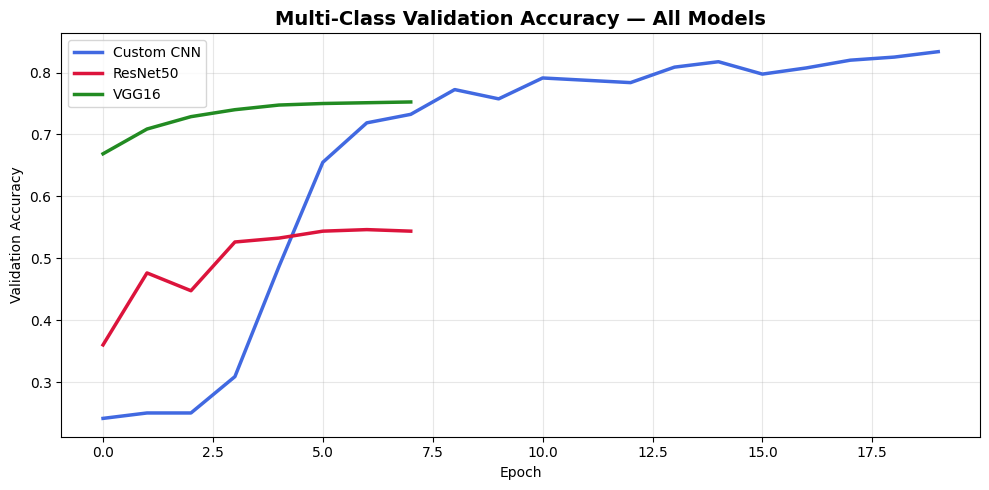


🏆 Multi-Class Classification — Final Comparison


,Model,Best Validation Accuracy (%),Best Validation Loss
0,Custom CNN,83.38,0.5293
1,VGG16,75.25,0.8332
2,ResNet50,54.62,1.1970


In [49]:
# =============================================================================
# CELL 17 — Multi-Class Accuracy Comparison Chart & Summary Table
# =============================================================================

# Overlay all three val_accuracy curves on one chart for easy comparison
plt.figure(figsize=(10, 5))

multiclass_curve_styles = [
    (mc_custom_cnn_history, 'Custom CNN',  'royalblue'),
    (mc_resnet50_history,   'ResNet50',    'crimson'),
    (mc_vgg16_history,      'VGG16',       'forestgreen'),
]

for history_obj, curve_label, curve_color in multiclass_curve_styles:
    plt.plot(history_obj.history['val_accuracy'],
             label=curve_label, linewidth=2.5, color=curve_color)

plt.title('Multi-Class Validation Accuracy — All Models',
          fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary DataFrame
multiclass_results_dict = {
    'Model': ['Custom CNN', 'ResNet50', 'VGG16'],
    'Best Validation Accuracy (%)': [
        round(max(mc_custom_cnn_history.history['val_accuracy']) * 100, 2),
        round(max(mc_resnet50_history.history['val_accuracy'])   * 100, 2),
        round(max(mc_vgg16_history.history['val_accuracy'])      * 100, 2),
    ],
    'Best Validation Loss': [
        round(min(mc_custom_cnn_history.history['val_loss']), 4),
        round(min(mc_resnet50_history.history['val_loss']),   4),
        round(min(mc_vgg16_history.history['val_loss']),      4),
    ]
}

multiclass_results_df = pd.DataFrame(multiclass_results_dict)
multiclass_results_df = multiclass_results_df.sort_values('Best Validation Accuracy (%)',
                                                           ascending=False)
print("\n🏆 Multi-Class Classification — Final Comparison")
display(multiclass_results_df.reset_index(drop=True))


In [50]:
# =============================================================================
# CELL 18 — Save All Trained Models to Disk
# =============================================================================
# Models are saved in the legacy HDF5 format (.h5) for broad compatibility.
# They can be reloaded with:  tf.keras.models.load_model('filename.h5')
# =============================================================================

models_to_save = [
    ('binary_vgg16.h5',          vgg16_classifier),
    ('binary_custom_cnn.h5',     custom_binary_cnn),
    ('binary_resnet50.h5',       resnet50_classifier),
    ('multiclass_custom_cnn.h5', mc_custom_cnn),
    ('multiclass_resnet50.h5',   mc_resnet50),
    ('multiclass_vgg16.h5',      mc_vgg16),
]

for save_filename, model_to_save in models_to_save:
    model_to_save.save(save_filename)
    print(f"✅ Saved: {save_filename}")

print("\n🎉 All models saved successfully.")


✅ Saved: binary_vgg16.h5
✅ Saved: binary_custom_cnn.h5


✅ Saved: binary_resnet50.h5
✅ Saved: multiclass_custom_cnn.h5


✅ Saved: multiclass_resnet50.h5
✅ Saved: multiclass_vgg16.h5

🎉 All models saved successfully.
